In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


2026-06-08 18:47:59.206035: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 18:47:59.792078: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 18:48:01.922078: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # dependendo da versão do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/davidsales/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/davidsales/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)

In [6]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"This is the kind of film they used to make, amusing, heart-warming, troubling, authentic, with convincing performances by people without nose jobs, boob jobs, eye jobs, in other words real people. Shauna Macdonald plays the female love interest, and she is so real you want to give her a cuddle at the very least. Imagine that, a real girl in a movie, whatever next? Hollywood would hate her, because her freshness is a sharp rebuke to every false starlet in Tinseltown. This story has the same hilarious feel as Sandy Mackendrick's classic 'Whisky Galore', with the gnomic humour of remote Scottish islanders puncturing the pretensions of intruders from outside and enjoying a wee dram from time to time (the actual intervals between those times often being rather short). Director Stephen Whittaker displays a rare skill in pulling this off just right, and it is shocking to discover that he died before his film's release, aged only 56, which was clearly a substantial loss to the screen. Ulrich 

In [7]:
print(preprocess(df.iloc[random_num]['review']))

kind film used make amusing heart warming troubling authentic convincing performance people without nose job boob job eye job word real people shauna macdonald play female love interest real want give cuddle least imagine real girl movie whatever next hollywood would hate freshness sharp rebuke every false starlet tinseltown story hilarious feel sandy mackendrick classic whisky galore gnomic humour remote scottish islander puncturing pretension intruder outside enjoying wee dram time time actual interval time often rather short director stephen whittaker display rare skill pulling right shocking discover died film release aged clearly substantial loss screen ulrich thomsen well playing german rocket scientist late scarp isle harris build small rocket carry postal packet island fall love alluring macdonald lass reciprocates affection wonderfully colourful local character decorate tale film pure delight course threat imminent war hitler learn hitler executed rocket scientist refused buil

In [8]:
df['review'] = df['review'].apply(preprocess)

In [9]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [11]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
max_len = 4

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [14]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(4, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

2026-06-08 18:49:17.058740: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 4, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,169 (313.16 KB)

 Trainable params: 80,169 (313.16 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [16]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5123 - loss: 0.6927 - val_accuracy: 0.5985 - val_loss: 0.6917 - learning_rate: 5.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5438 - loss: 0.6892 - val_accuracy: 0.6518 - val_loss: 0.6807 - learning_rate: 5.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5858 - loss: 0.6685 - val_accuracy: 0.6722 - val_loss: 0.6396 - learning_rate: 5.0000e-04
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6217 - loss: 0.6425 - val_accuracy: 0.6816 - val_loss: 0.6129 - learning_rate: 5.0000e-04
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6481 - loss: 0.6253 - val_accuracy: 0.6877 - val_loss: 0.5983 - learning_rate: 5.0000e-04
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6706 - loss: 0.6122 - val_accuracy: 0.6889 - val_loss: 0.5873 - learning_rate: 5.0000e-04
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 

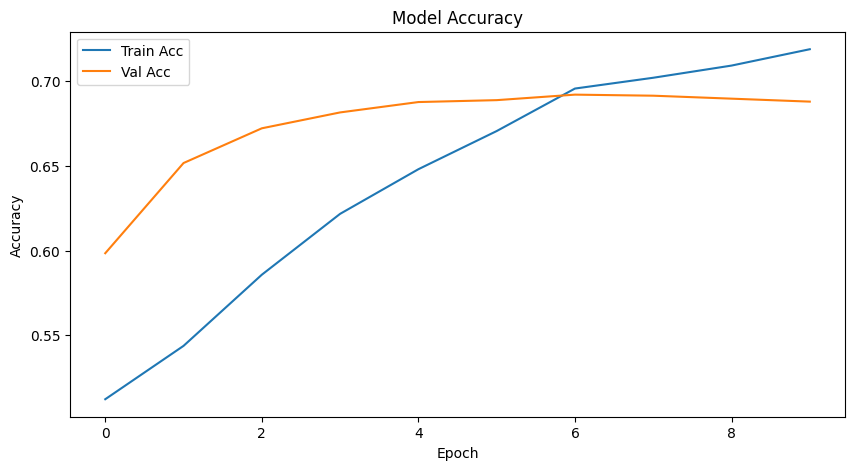

In [17]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6959 - loss: 0.5741
Test Accuracy: 0.695900022983551


## Confusion Matrices

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


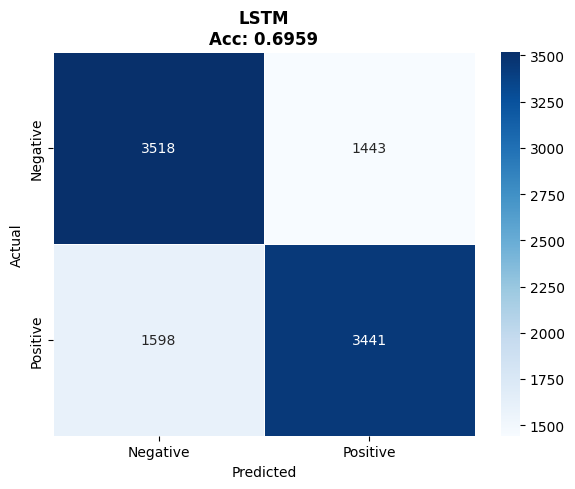

In [19]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Classification Reports

In [20]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.69      0.71      0.70      4961
    Positive       0.70      0.68      0.69      5039

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [21]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

In [22]:
texto_natural = "The movie was terrible"
texto_sem_stopwords = preprocess(texto_natural)

In [23]:
teste_qualquer = tokenizer.texts_to_sequences([texto_sem_stopwords])
teste_qualquer_pad = pad_sequences(teste_qualquer, maxlen=max_len)


In [24]:
# modelo de inspeção
layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

# entrada exemplo
x = teste_qualquer_pad

# forward
outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
Outputs salvos em layer_outputs.txt


In [25]:

FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)

# ============================================================
# ENDERECO DE 21 BITS
# ============================================================
def build_addr(layer, is_bias, is_lstm, gate, neuron, recurrent, idx):
    addr = 0
    addr |= (layer     & 0xF)   << 17  # bits 20-17: camada (max 16)
    addr |= (is_bias   & 0x1)   << 16  # bit 16:    bias
    addr |= (is_lstm   & 0x1)   << 15  # bit 15:    lstm
    addr |= (gate      & 0x3)   << 13  # bits 14-13: porta LSTM
    addr |= (neuron    & 0x3F)  << 7   # bits 12-7:  neuronio (max 64)
    addr |= (recurrent & 0x1)   << 6   # bit 6:     recorrente
    addr |= (idx       & 0x3F)        # bits 5-0:   indice (max 64)
    return addr

# ============================================================
# EXPORTA PESOS DA LSTM (ignorando Embedding)
# ============================================================
def export_lstm_weights(model, output_file="weights_lstm.mem"):
    print("\n" + "="*50)
    print("MODO LSTM: Exportando pesos a partir da primeira LSTM")
    print("Ignorando: Embedding e SpatialDropout1D")
    print("="*50)
    
    mem = {}
    layer_idx = 0  # camada 0 = primeira LSTM
    
    # Percorre as camadas do modelo
    for layer in model.layers:
        # Pula camadas que nao tem pesos
        if len(layer.get_weights()) == 0:
            continue
            
        # Verifica se é LSTM (incluindo Bidirectional)
        if isinstance(layer, Bidirectional):
            # Bidirectional tem 2 LSTMs (forward e backward)
            print(f"\nCamada {layer_idx}: Bidirectional LSTM")
            
            forward_lstm = layer.forward_layer
            backward_lstm = layer.backward_layer
            
            # Exporta forward LSTM
            export_lstm_core(forward_lstm, mem, layer_idx, direction=0)
            # Exporta backward LSTM (proxima camada)
            export_lstm_core(backward_lstm, mem, layer_idx + 1, direction=1)
            
            layer_idx += 2  # Duas camadas (forward e backward)
            
        elif isinstance(layer, LSTM):
            print(f"\nCamada {layer_idx}: LSTM")
            export_lstm_core(layer, mem, layer_idx, direction=0)
            layer_idx += 1
            
        elif isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
    
    # Salva arquivo
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# EXPORTA PESOS DA LSTM (core)
# ============================================================
def export_lstm_core(lstm_layer, mem, layer_idx, direction=0):
    """
    Exporta pesos de uma camada LSTM
    direction: 0 = forward, 1 = backward (apenas para identificacao)
    """
    weights = lstm_layer.get_weights()
    
    # LSTM tem 3 matrizes de pesos e 3 biases (ou 2 se usar bias=False)
    # weights[0]: kernel (input weights) - formato: (input_dim, 4 * units)
    # weights[1]: recurrent_kernel (recurrent weights) - formato: (units, 4 * units)
    # weights[2]: bias (se existir) - formato: (4 * units,)
    
    units = lstm_layer.units
    input_dim = weights[0].shape[0]
    
    # Separa os pesos para cada porta (forget, input, candidate, output)
    # Ordem: i, f, c, o (input, forget, candidate, output)
    kernel = weights[0].T  # Transpoe para (4*units, input_dim)
    recurrent_kernel = weights[1].T  # Transpoe para (4*units, units)
    
    # Bias
    has_bias = len(weights) > 2
    if has_bias:
        bias = weights[2]
    else:
        bias = np.zeros(4 * units)
    
    # Para cada porta
    gates = ['forget', 'input', 'candidate', 'output']
    
    for gate_idx, gate_name in enumerate(gates):
        # Pesos de entrada (Wx)
        kernel_gate = kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for inp in range(input_dim):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel_gate[n, inp])
                
                # Mostra alguns exemplos (opcional)
                if n < 2 and inp < 2:
                    print(f"  addr=0x{addr:05X} Wx_{gate_name}[{n}][{inp}] = {kernel_gate[n, inp]:.6f}")
        
        # Pesos recorrentes (Wh)
        rec_gate = recurrent_kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for prev_n in range(units):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=1,
                    idx=prev_n
                )
                mem[addr] = float_to_q16(rec_gate[n, prev_n])
                
                if n < 2 and prev_n < 2:
                    print(f"  addr=0x{addr:05X} Wh_{gate_name}[{n}][{prev_n}] = {rec_gate[n, prev_n]:.6f}")
        
        # Bias
        bias_gate = bias[gate_idx * units:(gate_idx + 1) * units]
        for n in range(units):
            addr = build_addr(
                layer=layer_idx,
                is_bias=1,
                is_lstm=1,
                gate=gate_idx,
                neuron=n,
                recurrent=0,
                idx=0
            )
            mem[addr] = float_to_q16(bias_gate[n])
            
            if n < 2:
                print(f"  addr=0x{addr:05X} bias_{gate_name}[{n}] = {bias_gate[n]:.6f}")

# ============================================================
# EXPORTA PESOS DA DENSE (MLP comum)
# ============================================================
def export_dense_core(dense_layer, mem, layer_idx):
    """Exporta pesos de uma camada Dense"""
    weights = dense_layer.get_weights()
    
    if len(weights) >= 1:
        kernel = weights[0].T  # Transpoe para (output_dim, input_dim)
        n_neurons, n_inputs = kernel.shape
        
        # Pesos
        for n in range(n_neurons):
            for inp in range(n_inputs):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=0,  # Nao é LSTM
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel[n, inp])
                
                if n < 3 and inp < 3:
                    print(f"  addr=0x{addr:05X} weight[{n}][{inp}] = {kernel[n, inp]:.6f}")
        
        # Biases
        if len(weights) >= 2:
            bias = weights[1]
            for n in range(n_neurons):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=1,
                    is_lstm=0,
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=0
                )
                mem[addr] = float_to_q16(bias[n])
                
                if n < 3:
                    print(f"  addr=0x{addr:05X} bias[{n}] = {bias[n]:.6f}")

# ============================================================
# EXPORTA COMO MLP (ignorando LSTM)
# ============================================================
def export_mlp_weights(model, output_file="weights_mlp.mem"):
    print("\n" + "="*50)
    print("MODO MLP: Exportando pesos como rede neural comum")
    print("Todas as camadas Dense sao consideradas")
    print("="*50)
    
    mem = {}
    layer_idx = 0
    
    for layer in model.layers:
        if len(layer.get_weights()) == 0:
            continue
            
        if isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
        elif isinstance(layer, Bidirectional) or isinstance(layer, LSTM):
            print(f"\nAviso: Pulando camada LSTM no modo MLP")
            continue
    
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# FUNCAO PRINCIPAL
# ============================================================
def export_weights(model, mode='lstm', output_file=None):
    """
    Exporta pesos do modelo
    
    Args:
        model: Modelo Keras
        mode: 'lstm' (ignora Embedding) ou 'mlp' (apenas camadas Dense)
        output_file: Nome do arquivo de saida
    """
    if mode == 'lstm':
        if output_file is None:
            output_file = "weights_lstm.mem"
        return export_lstm_weights(model, output_file)
    elif mode == 'mlp':
        if output_file is None:
            output_file = "weights_mlp.mem"
        return export_mlp_weights(model, output_file)
    else:
        raise ValueError("Modo deve ser 'lstm' ou 'mlp'")



In [26]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_forget[0][0] = 0.475398
  addr=0x08001 Wx_forget[0][1] = -0.131975
  addr=0x08080 Wx_forget[1][0] = 0.299689
  addr=0x08081 Wx_forget[1][1] = -0.639353
  addr=0x08040 Wh_forget[0][0] = 0.044177
  addr=0x08041 Wh_forget[0][1] = -0.616195
  addr=0x080C0 Wh_forget[1][0] = 0.475894
  addr=0x080C1 Wh_forget[1][1] = 0.017817
  addr=0x18000 bias_forget[0] = 0.629342
  addr=0x18080 bias_forget[1] = 0.377211
  addr=0x0A000 Wx_input[0][0] = 0.052552
  addr=0x0A001 Wx_input[0][1] = 0.758627
  addr=0x0A080 Wx_input[1][0] = -0.444765
  addr=0x0A081 Wx_input[1][1] = 0.075789
  addr=0x0A040 Wh_input[0][0] = 0.486674
  addr=0x0A041 Wh_input[0][1] = -0.334546
  addr=0x0A0C0 Wh_input[1][0] = -0.278572
  addr=0x0A0C1 Wh_input[1][1] = -0.268128
  addr=0x1A000 bias_input[0] = 1.337592
  addr=0x1A080 bias_input[1] = 1.108220
  addr=0x0C000 Wx_candidate[0][0] = 0.847233
  addr=0x0C

In [27]:
lstm_model.weights[2][0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([ 0.04417678,  0.47589353, -0.33939546,  0.05774587,  0.48667404,
       -0.2785721 ,  0.1410796 , -0.19479485,  0.29457596, -0.36950868,
       -0.3844772 , -0.2716528 , -0.34568515,  0.10330264,  0.19251354,
       -0.2237594 ], dtype=float32)>

In [28]:
lstm_model.weights[5]

<Variable path=sequential/dense/bias, shape=(4,), dtype=float32, value=[0.14057142 0.12564202 0.1081543  0.0836449 ]>

In [29]:
# Modo 1: A partir da LSTM (ignorando Embedding)
#export_weights(lstm_model, mode='lstm', output_file="weights_lstm.mem")

# Modo 2: Como MLP comum (apenas camadas Dense)
export_weights(lstm_model, mode='mlp', output_file="weights_mlp.mem")

print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO MLP: Exportando pesos como rede neural comum
Todas as camadas Dense sao consideradas

Aviso: Pulando camada LSTM no modo MLP

Camada 0: Dense
  addr=0x00000 weight[0][0] = -1.043995
  addr=0x00001 weight[0][1] = 0.493536
  addr=0x00002 weight[0][2] = 0.875800
  addr=0x00080 weight[1][0] = -1.133537
  addr=0x00081 weight[1][1] = 0.995323
  addr=0x00082 weight[1][2] = 0.277174
  addr=0x00100 weight[2][0] = 0.990507
  addr=0x00101 weight[2][1] = -0.832112
  addr=0x00102 weight[2][2] = -1.071674
  addr=0x10000 bias[0] = 0.140571
  addr=0x10080 bias[1] = 0.125642
  addr=0x10100 bias[2] = 0.108154

Camada 1: Dense
  addr=0x20000 weight[0][0] = 0.790004
  addr=0x20001 weight[0][1] = 0.814581
  addr=0x20002 weight[0][2] = -1.342144
  addr=0x30000 bias[0] = -0.226790

Arquivo salvo: weights_mlp.mem
Total de pesos: 25

############################################################
CONCLUIDO!
############################################################
